# SDSS-V APOGEE Selection Function Tutorial

This notebook shows how to use `sdssv_apogee_sf` to compute and visualise an SDSS-V APOGEE selection function.

We use the publicly available **ASPCAP DR 0.6.0** summary file and the **Galactic Genesis (GG)** programme as a worked example.

### What is the selection function?

The selection function $S(\ell, b, H, G{-}H)$ is the probability that a 2MASS star at a given sky position and magnitude was observed by APOGEE. It is estimated as:

$$S = \frac{N_\mathrm{observed} + 1}{N_\mathrm{2MASS} + 2}$$

using a Bayesian Beta(1,1) prior. The denominator $N_\mathrm{2MASS}$ is a pre-computed count of 2MASS PSC sources per sky pixel and magnitude bin; the numerator $N_\mathrm{observed}$ comes from the user's observed-star table.

The sky is pixelised with HEALPix. Pixels with too few 2MASS sources are adaptively merged to a coarser resolution.

### Two modes
| Mode | Columns needed | SF axes |
|------|----------------|---------|
| H-only | `ra`, `dec`, `h_mag` | H bin × pixel |
| H + G−H (colour) | `ra`, `dec`, `h_mag`, `g_mag` | H bin × pixel × G−H bin |

## 0. Setup

In [1]:
import sys
import importlib.resources
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import healpy as hp
import astropy.table as tbl
import astropy.coordinates as coord
from astropy.io import fits as astrofits

# Point to the package src directory
sys.path.insert(0, str(Path('.') / 'src'))
from sdssv_apogee_sf import APOGEESelectionFunction

# Limits and resolution come from the bundled denominator file.
pkg_data = importlib.resources.files("sdssv_apogee_sf") / "data" / "twomass_denominator.npz"
with importlib.resources.as_file(pkg_data) as p:
    _d = np.load(p)
    _H  = _d['H_BINS']
    _GH = _d['GH_BINS']

print(f'Denominator H limits:   [{_H[0]:.1f}, {_H[-1]:.1f}] mag  '
      f'(minimum bin size {_H[1]-_H[0]:.1f} mag)')
print(f'Denominator G−H limits: [{_GH[0]:.1f}, {_GH[-1]:.1f}] mag  '
      f'(minimum bin size {_GH[1]-_GH[0]:.1f} mag)')

Denominator H limits:   [-3.0, 18.0] mag  (minimum bin size 0.5 mag)
Denominator G−H limits: [-2.5, 14.5] mag  (minimum bin size 0.5 mag)


## 1. Load and prepare the observed GG sample

We use the public **astraAllStarASPCAP-0.6.0.fits.gz** file.  
Download it from the [SDSS DR19 summary file page](https://data.sdss.org/sas/dr19/spectro/astra/0.6.0/summary/) and set `FITS_PATH` below.

In [2]:
FITS_PATH = Path('~/Downloads/astraAllStarASPCAP-0.6.0.fits.gz').expanduser()

with astrofits.open(FITS_PATH) as hdul:
    data = hdul[2].data

print(f'Total rows in ASPCAP 0.6.0: {len(data):,}')

Total rows in ASPCAP 0.6.0: 1,095,480


In [3]:
# ── Filter to Galactic Genesis programme using sdss-semaphore ────────────────
# Install: pip install sdss-semaphore
try:
    from sdss_semaphore.targeting import TargetingFlags
except ImportError:
    from semaphore.targeting import TargetingFlags

tf   = TargetingFlags(np.asarray(data['sdss5_target_flags']))
mask = (np.asarray(tf.in_program('mwm_galactic'), dtype=bool) |
        np.asarray(tf.in_program('mwm_gg'),       dtype=bool))

sub = data[mask]
print(f'After GG filter: {len(sub):,} / {len(data):,} rows')

After GG filter: 251,357 / 1,095,480 rows


In [4]:
# ── Deduplicate on sdss_id ────────────────────────────────────────────────────
# If the same sdss_id appears with different obj values the Gaia cross-match is
# ambiguous — drop those groups entirely.  Otherwise keep the first row per sdss_id.
sdss_ids = np.asarray(sub['sdss_id'], dtype=np.int64)
objs     = np.char.strip(np.asarray(sub['obj'], dtype=str))

order     = np.argsort(sdss_ids, kind='stable')
s_ids, s_objs = sdss_ids[order], objs[order]

is_first  = np.concatenate([[True], s_ids[1:] != s_ids[:-1]])
group_idx = np.cumsum(is_first) - 1
grp_count = np.bincount(group_idx)
first_obj = s_objs[is_first]

grp_mismatch = np.zeros(len(first_obj), dtype=bool)
np.logical_or.at(grp_mismatch, group_idx, s_objs != first_obj[group_idx])
bad_group       = (grp_count > 1) & grp_mismatch
bad_row         = np.empty(len(sub), dtype=bool)
bad_row[order]  = bad_group[group_idx]

good     = sub[~bad_row]
_, keep  = np.unique(np.asarray(good['sdss_id'], dtype=np.int64), return_index=True)
sub      = good[keep]
print(f'After sdss_id dedup: {len(sub):,}')

After sdss_id dedup: 235,276


In [5]:
# ── Deduplicate on 2MASS designation ─────────────────────────────────────────
# Each 2MASS star should appear at most once in the numerator to match
# how the denominator counts 2MASS PSC sources.
# The obj column uses a '2M' prefix for most entries; strip it to get the
# raw twomass_psc designation format.
raw_objs = np.char.strip(np.asarray(sub['obj'], dtype=str))
desigs   = np.array([o[2:] if o.startswith('2M') else o for o in raw_objs])

valid    = desigs != ''
sub, desigs = sub[valid], desigs[valid]

_, keep  = np.unique(desigs, return_index=True)
sub, desigs = sub[keep], desigs[keep]
print(f'After 2MASS dedup: {len(sub):,} unique stars')

After 2MASS dedup: 235,225 unique stars


In [6]:
# ── Extract magnitudes ────────────────────────────────────────────────────────
# ASPCAP 0.6.0 includes 2MASS H and Gaia G directly.
# Sentinel values (−999999, 99.99…) are replaced with NaN.
h_mag = np.asarray(sub['h_mag'], dtype=float)
g_mag = np.asarray(sub['g_mag'], dtype=float)

h_mag[(h_mag < -100) | (h_mag > 20)] = np.nan
g_mag[(g_mag <= 0)   | (g_mag > 22)] = np.nan

has_h  = np.isfinite(h_mag)
has_hg = has_h & np.isfinite(g_mag)
print(f'Stars with valid H:       {has_h.sum():,}  ({100*has_h.mean():.1f}%)')
print(f'Stars with valid H and G: {has_hg.sum():,}  ({100*has_hg.mean():.1f}%)')

Stars with valid H:       235,219  (100.0%)
Stars with valid H and G: 229,252  (97.5%)


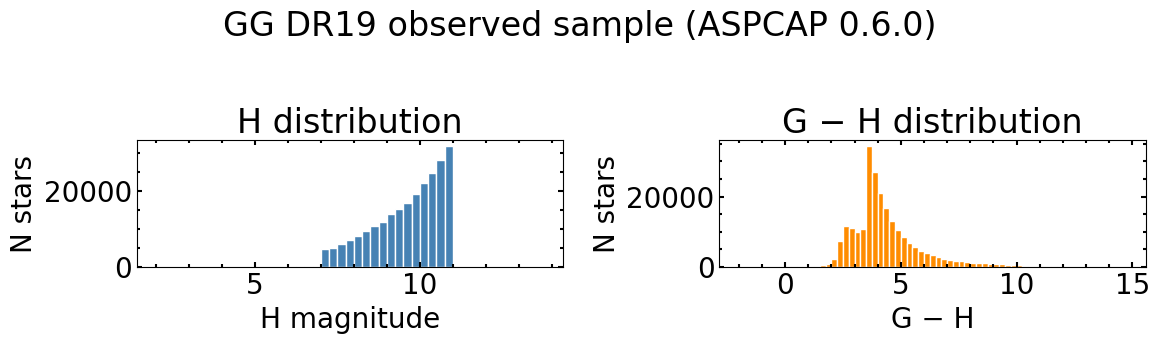

In [7]:
# Assemble the observed table
observed = tbl.Table({
    'ra'    : np.asarray(sub['ra'],  dtype=float),
    'dec'   : np.asarray(sub['dec'], dtype=float),
    'h_mag' : h_mag,
    'g_mag' : g_mag,
})

# H-magnitude distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(h_mag[has_h], bins=np.arange(2, 14, 0.25),
             color='steelblue', edgecolor='white', lw=0.3)
axes[0].set_xlabel('H magnitude')
axes[0].set_ylabel('N stars')
axes[0].set_title('H distribution')

axes[1].hist((g_mag - h_mag)[has_hg], bins=np.arange(-2, 15, 0.25),
             color='darkorange', edgecolor='white', lw=0.3)
axes[1].set_xlabel('G − H')
axes[1].set_ylabel('N stars')
axes[1].set_title('G − H distribution')

fig.suptitle('GG DR19 observed sample (ASPCAP 0.6.0)', y=1.01)
fig.tight_layout()
plt.show()

## 2. The 2MASS denominator

The denominator (2MASS PSC counts per HEALPix pixel, H-magnitude bin, and G−H bin) is **bundled with the package** — no download or path configuration required.

The cell below loads it via `importlib.resources` to inspect its coverage.

In [8]:
import importlib.resources

pkg_data = importlib.resources.files("sdssv_apogee_sf") / "data" / "twomass_denominator.npz"
with importlib.resources.as_file(pkg_data) as p:
    d = np.load(p)
    H_BINS  = d['H_BINS']
    GH_BINS = d['GH_BINS']
    nside   = int(d['nside'])
    shape   = d['hist_all'].shape
    total   = int(d['hist_all'].sum())

print(f'Denominator shape:  {shape}  (n_H, n_pix, n_GH)')
print(f'H coverage:  [{H_BINS[0]:.1f}, {H_BINS[-1]:.1f}] mag  '
      f'({len(H_BINS)-1} bins, step {H_BINS[1]-H_BINS[0]:.1f} mag)')
print(f'GH coverage: [{GH_BINS[0]:.1f}, {GH_BINS[-1]:.1f}] mag  '
      f'({len(GH_BINS)-1} bins, step {GH_BINS[1]-GH_BINS[0]:.1f} mag)')
print(f'nside:       {nside}  (pixel size ≈ {hp.nside2resol(nside, arcmin=True):.0f} arcmin)')
print(f'Total 2MASS sources: {total:,}')

Denominator shape:  (42, 49152, 34)  (n_H, n_pix, n_GH)
H coverage:  [-3.0, 18.0] mag  (42 bins, step 0.5 mag)
GH coverage: [-2.5, 14.5] mag  (34 bins, step 0.5 mag)
nside:       64  (pixel size ≈ 55 arcmin)
Total 2MASS sources: 545,822,717


## 3. Build the selection function

### 3a. H-only (2D)

In [9]:
import warnings

sf_h = APOGEESelectionFunction.from_observed(
    observed,
    ra_col  = 'ra',
    dec_col = 'dec',
    h_col   = 'h_mag',
    # g_col not provided → H-only mode; denominator summed over G−H
    # By default the H range is restricted to the min/max of the input table.
    # To set explicit limits (must be within the denominator bounds):
    # h_range = (7.0, 13.5),
    # To coarsen bins (must be a multiple of the native 0.5-mag step):
    # h_bin_size = 1.0,
    min_count = 5,
    nside_min = 8,
)

print(f'SF shape (H-only): {sf_h._selfunc.shape}   (n_H, n_pix)')
print(f'H range used: [{sf_h.H_BINS[0]:.1f}, {sf_h.H_BINS[-1]:.1f}]  ({len(sf_h.H_BINS)-1} bins)')

SF shape (H-only): (28, 49152)   (n_H, n_pix)
H range used: [-2.5, 11.5]  (28 bins)


### 3b. H + G−H colour mode (3D)

In [10]:
sf_c = APOGEESelectionFunction.from_observed(
    observed,
    ra_col  = 'ra',
    dec_col = 'dec',
    h_col   = 'h_mag',
    g_col   = 'g_mag',   # enables colour mode
    # By default H and G−H ranges are restricted to the min/max of the input table.
    # To set explicit limits (must be within the denominator bounds):
    # h_range  = (7.0, 13.5),
    # gh_range = (0.0, 8.0),
    # To coarsen bins (must be a multiple of the native 0.5-mag step):
    # h_bin_size  = 1.0,
    # gh_bin_size = 1.0,
    min_count = 5,
    nside_min = 8,
)

print(f'SF shape (colour): {sf_c._selfunc.shape}   (n_H, n_pix, n_GH)')
print(f'H range used:  [{sf_c.H_BINS[0]:.1f}, {sf_c.H_BINS[-1]:.1f}]  ({len(sf_c.H_BINS)-1} bins)')
print(f'GH range used: [{sf_c.GH_BINS[0]:.1f}, {sf_c.GH_BINS[-1]:.1f}]  ({len(sf_c.GH_BINS)-1} bins)')

SF shape (colour): (28, 49152, 33)   (n_H, n_pix, n_GH)
H range used:  [-2.5, 11.5]  (28 bins)
GH range used: [-2.5, 14.0]  (33 bins)


## 4. Save and reload

In [11]:
sf_h.write('gg_sf_honly.npz')
sf_c.write('gg_sf_color.npz')

# Reload from disk
sf_h = APOGEESelectionFunction.read('gg_sf_honly.npz')
sf_c = APOGEESelectionFunction.read('gg_sf_color.npz')
print('Reloaded H-only:', sf_h._selfunc.shape)
print('Reloaded colour:', sf_c._selfunc.shape)

Reloaded H-only: (28, 49152)
Reloaded colour: (28, 49152, 33)


## 5. Visualise: sky maps

In [12]:
def make_mollweide(sf_slice, hist_slice, nside, title, vmin=0, vmax=1, min_count=0):
    """Mollweide HEALPix map (equatorial pixels, displayed in Galactic coords)."""
    m = sf_slice.copy().astype(float)
    m[hist_slice < min_count] = np.nan
    m[~np.isfinite(m)] = hp.UNSEEN

    fig = plt.figure(figsize=(10, 5))
    hp.mollview(m, fig=fig.number, title=title,
                min=vmin, max=vmax, cmap='viridis',
                coord=['C', 'G'], unit='completeness',
                bgcolor='white', badcolor='lightgray')
    hp.graticule(dpar=30, dmer=60, alpha=0.4)
    cb_ax = fig.axes[-1]
    ticks = np.linspace(vmin, vmax, 6)
    cb_ax.xaxis.set_ticks(ticks)
    cb_ax.xaxis.set_ticklabels([f'{t:.2f}' for t in ticks])
    for txt in cb_ax.texts:
        x, y = txt.get_position()
        txt.set_position((x, y - 1.2))
    return fig

/opt/anaconda3/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


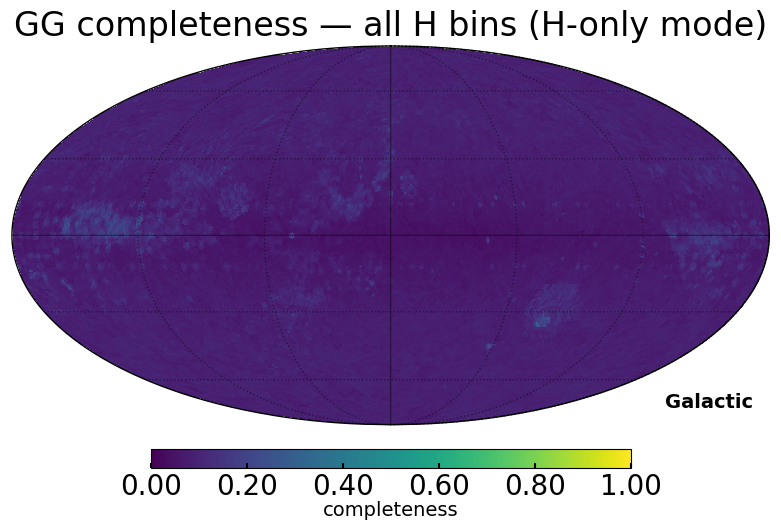

In [13]:
# ── H-only: summary map (mean over all H bins) ────────────────────────────────
sf  = sf_h._selfunc    # (n_H, n_pix)
ha  = sf_h._hist_all   # (n_H, n_pix)

fig = make_mollweide(
    np.nanmean(sf, axis=0), ha.sum(axis=0), nside,
    title='GG completeness — all H bins (H-only mode)'
)
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


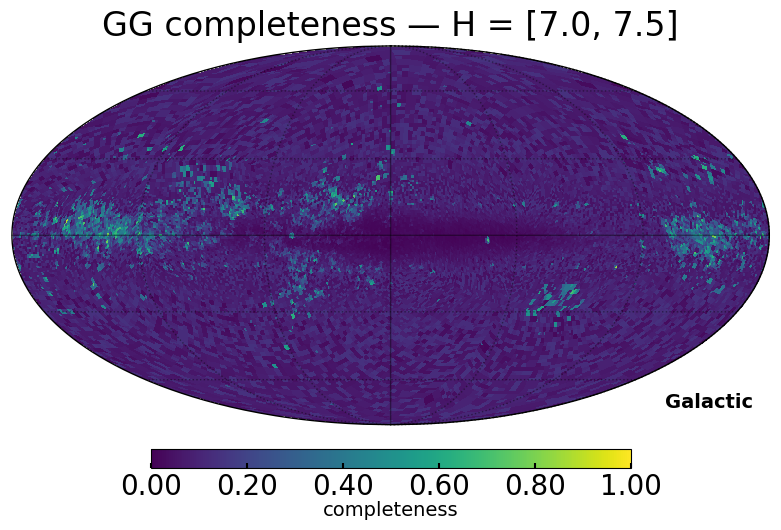

/opt/anaconda3/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


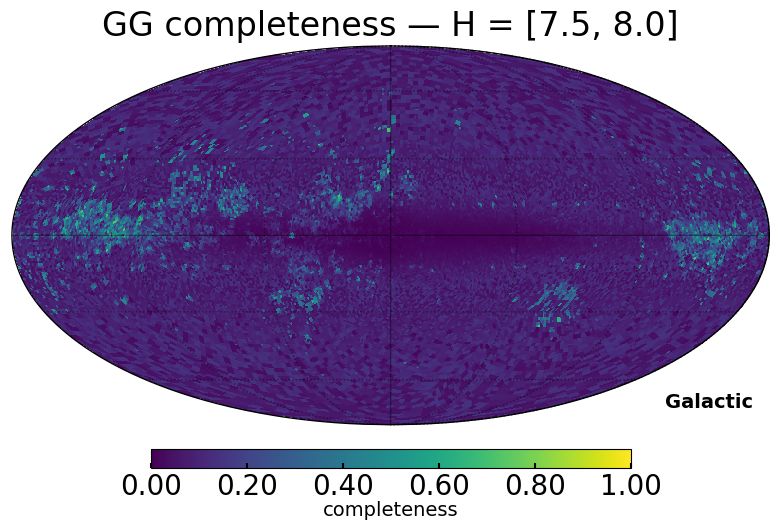

/opt/anaconda3/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


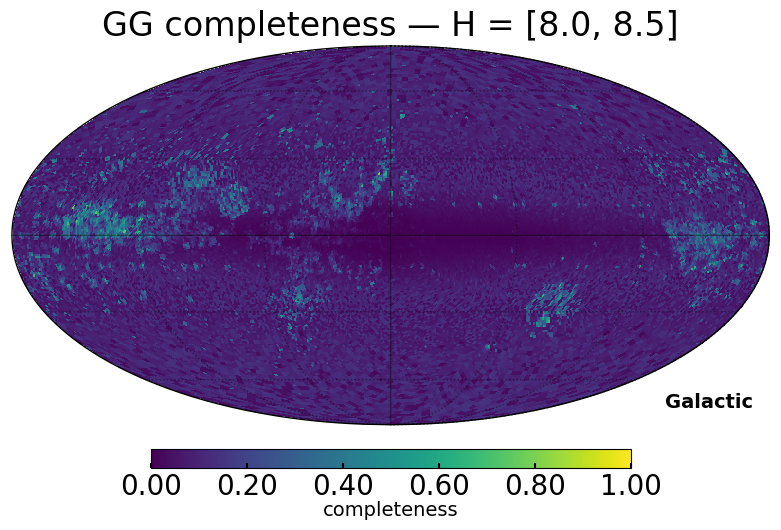

/opt/anaconda3/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


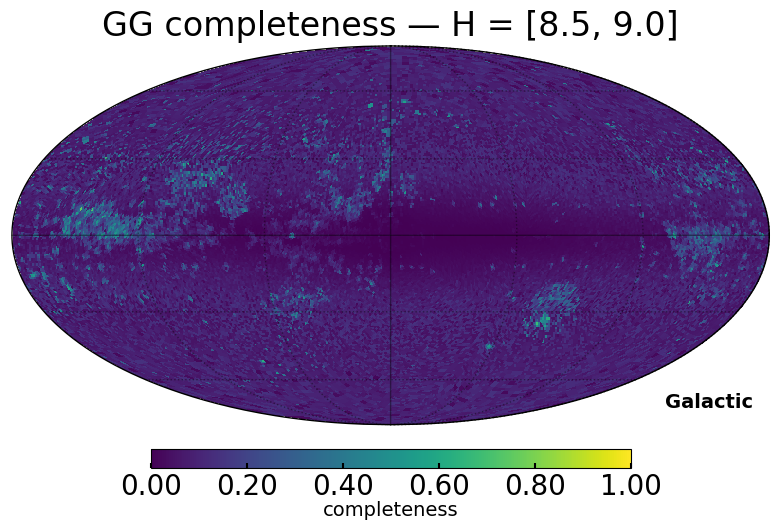

/opt/anaconda3/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


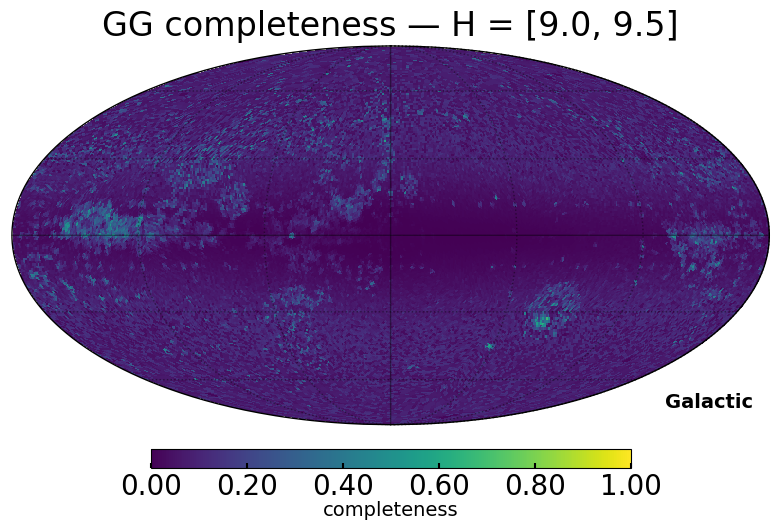

/opt/anaconda3/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


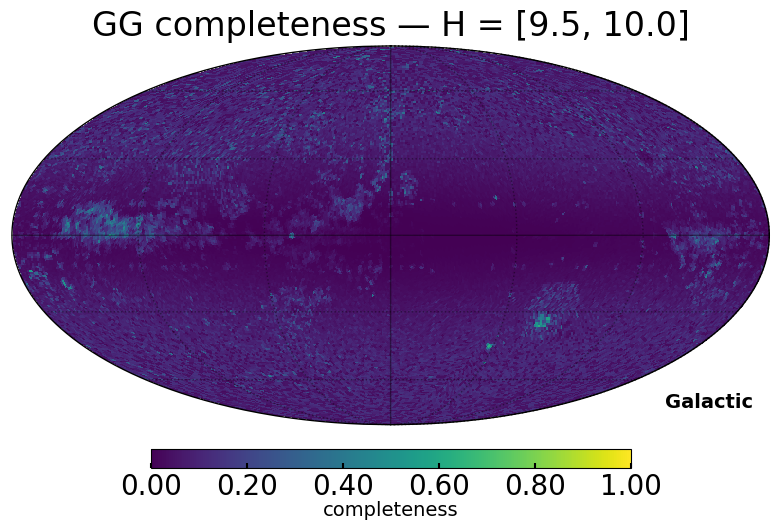

/opt/anaconda3/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


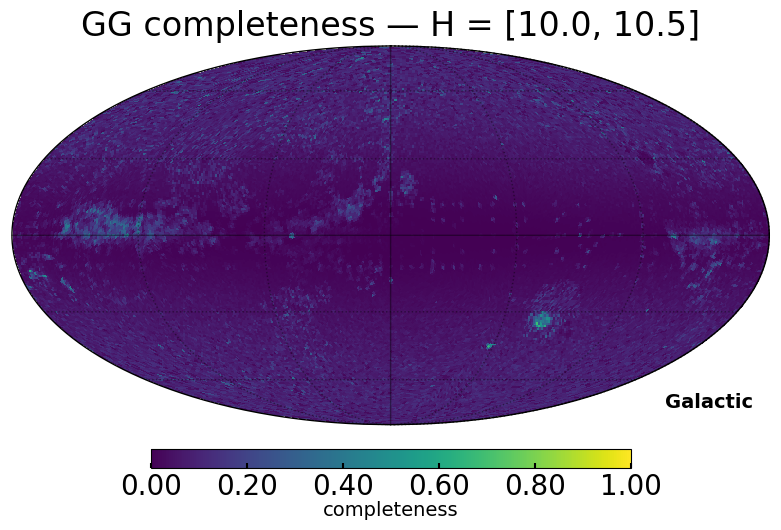

In [14]:
# ── H-only: one map per H bin (show a subset) ─────────────────────────────────
plot_h_bins = [i for i, h in enumerate(sf_h.H_BINS[:-1]) if 7.0 <= h <= 10.0]

for i in plot_h_bins:
    h_lo, h_hi = sf_h.H_BINS[i], sf_h.H_BINS[i+1]
    fig = make_mollweide(
        sf[i], ha[i], nside,
        title=f'GG completeness — H = [{h_lo:.1f}, {h_hi:.1f}]'
    )
    plt.show()

/opt/anaconda3/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


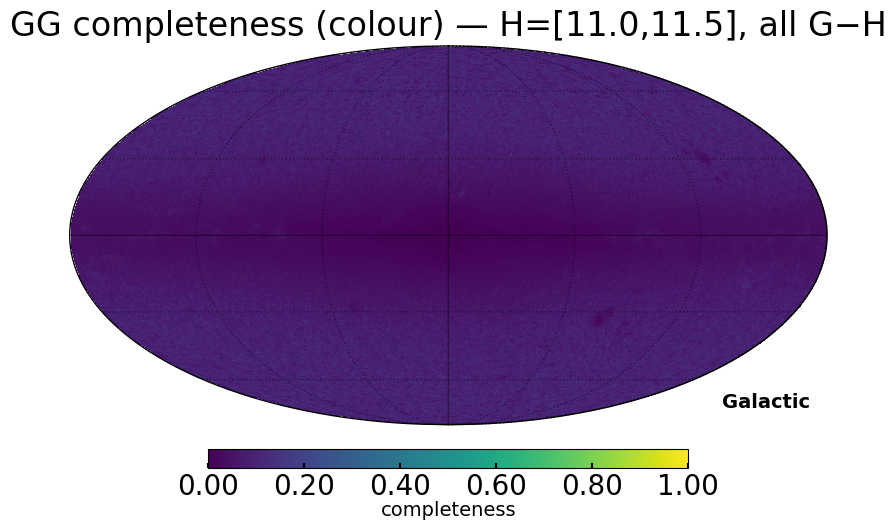

/opt/anaconda3/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


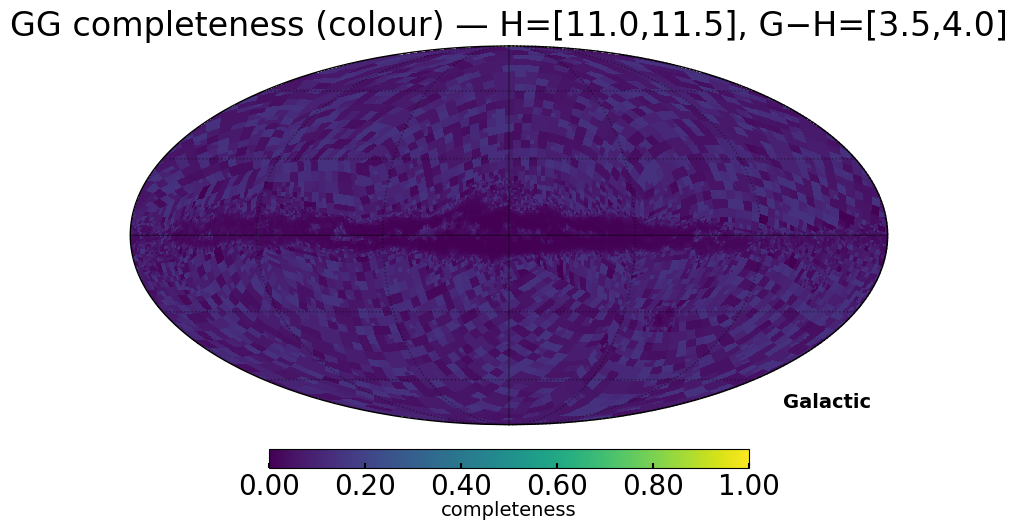

In [15]:
# ── Colour mode: sky map at the faintest H bin, summed over G−H ───────────────
h_last = len(sf_c.H_BINS) - 2
h_lo, h_hi = sf_c.H_BINS[h_last], sf_c.H_BINS[h_last + 1]

ha_sum = sf_c._hist_all[h_last].sum(axis=1)   # sum over GH → (n_pix,)
with np.errstate(invalid='ignore', divide='ignore'):
    sf_sum = np.where(
        ha_sum > 0,
        np.nansum(sf_c._selfunc[h_last] * sf_c._hist_all[h_last], axis=1) / ha_sum,
        np.nan
    )

fig = make_mollweide(
    sf_sum, ha_sum, nside,
    title=f'GG completeness (colour) — H=[{h_lo:.1f},{h_hi:.1f}], all G−H'
)
plt.show()

# A specific G−H slice
gh_target = 4.0
gi = np.clip(np.searchsorted(sf_c.GH_BINS[1:], gh_target), 0, len(sf_c.GH_BINS) - 2)
gh_lo, gh_hi = sf_c.GH_BINS[gi], sf_c.GH_BINS[gi + 1]

fig = make_mollweide(
    sf_c._selfunc[h_last, :, gi], sf_c._hist_all[h_last, :, gi], nside,
    title=f'GG completeness (colour) — H=[{h_lo:.1f},{h_hi:.1f}], G−H=[{gh_lo:.1f},{gh_hi:.1f}]'
)
plt.show()

## 6. Visualise: colour-magnitude diagram (CMD)

The CMD shows completeness as a function of H magnitude and G−H colour, averaged over sky pixels weighted by the 2MASS source count.

In [16]:
def plot_cmd(sf_obj, title, pixel_mask=None, vmax=1.0, min_count=0):
    """CMD: completeness(H, G−H) averaged over pixels (or a masked region)."""
    sf3 = sf_obj._selfunc    # (n_H, n_pix, n_GH)
    ha3 = sf_obj._hist_all

    if pixel_mask is not None:
        sf3 = sf3[:, pixel_mask, :]
        ha3 = ha3[:, pixel_mask, :]

    ha = ha3.sum(axis=1)   # (n_H, n_GH)
    with np.errstate(invalid='ignore', divide='ignore'):
        sf = np.where(ha >= max(min_count, 1),
                      np.nansum(sf3 * ha3, axis=1) / ha,
                      np.nan)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.pcolormesh(
        sf_obj.GH_BINS, sf_obj.H_BINS, sf,
        norm=mcolors.Normalize(vmin=0, vmax=vmax, clip=True),
        cmap='viridis', shading='flat'
    )
    fig.colorbar(im, ax=ax, label='completeness')
    ax.set_xlabel('G − H')
    ax.set_ylabel('H')
    ax.invert_yaxis()
    ax.set_title(title)
    fig.tight_layout()
    return fig


def pixel_mask_for_lb(nside, l_deg, b_deg, radius_deg=5.0):
    """Boolean pixel mask for a cone in Galactic coordinates."""
    rot = hp.Rotator(coord=['G', 'C'])   # galactic → equatorial
    theta_eq, phi_eq = rot(np.radians(90 - b_deg), np.radians(l_deg))
    vec  = hp.ang2vec(theta_eq, phi_eq)
    mask = np.zeros(hp.nside2npix(nside), dtype=bool)
    mask[hp.query_disc(nside, vec, np.radians(radius_deg))] = True
    return mask

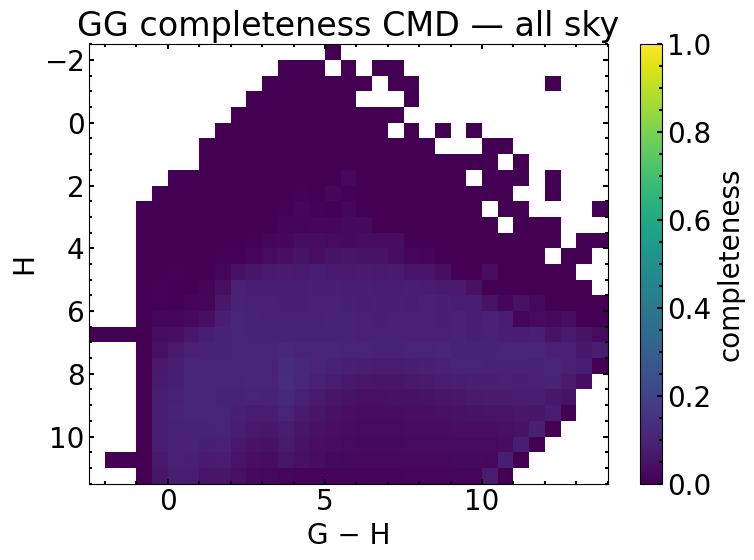

In [17]:
# All-sky CMD
fig = plot_cmd(sf_c, title='GG completeness CMD — all sky')
plt.show()

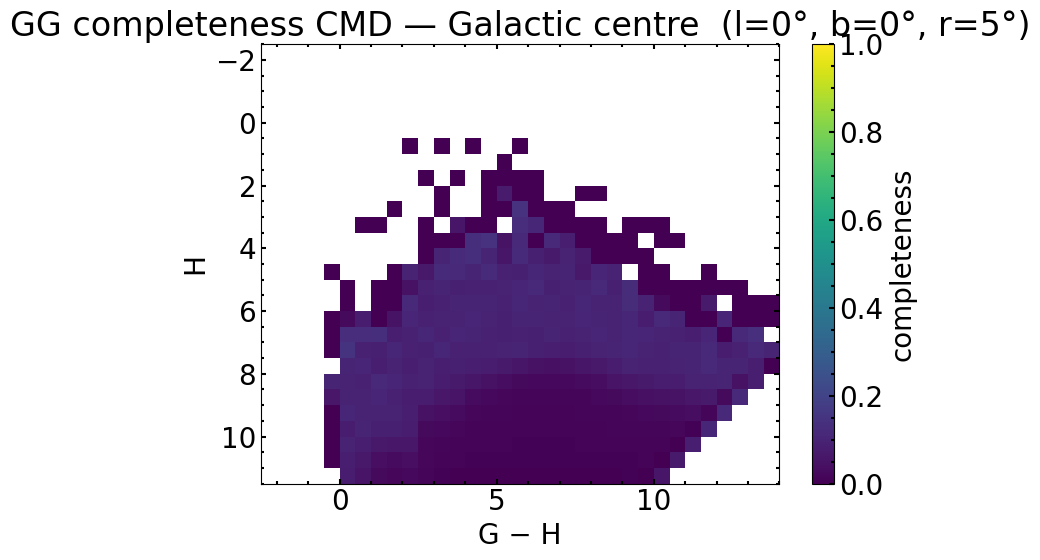

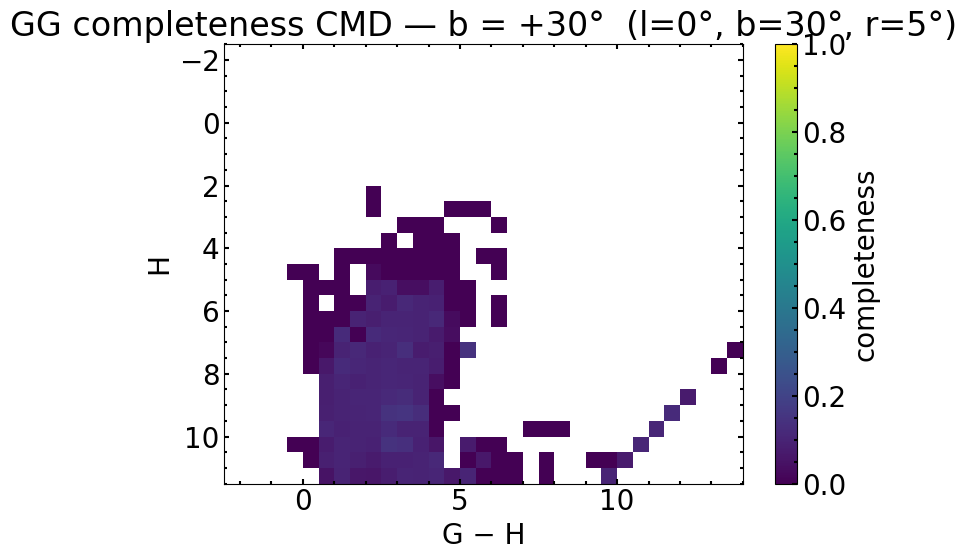

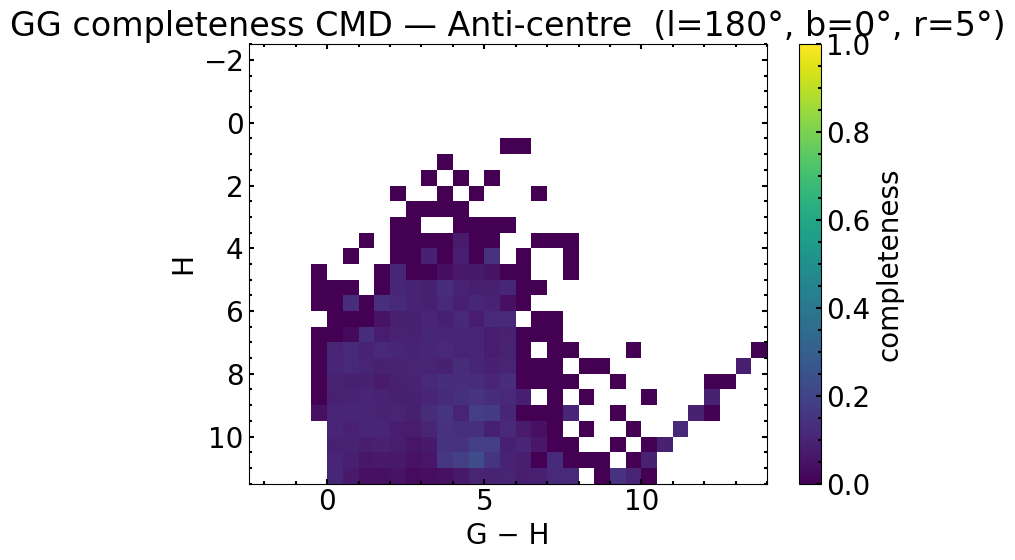

In [18]:
# CMDs at specific Galactic locations
locations = [
    (  0,  0, 'Galactic centre'),
    (  0, 30, 'b = +30°'),
    (180,  0, 'Anti-centre'),
]

for l, b, name in locations:
    mask = pixel_mask_for_lb(nside, l, b, radius_deg=5.0)
    fig  = plot_cmd(
        sf_c,
        title=f'GG completeness CMD — {name}  (l={l}°, b={b}°, r=5°)',
        pixel_mask=mask
    )
    plt.show()

## 7. Query the selection function

`sf.query(coords, H, GH)` returns the completeness for any list of sky positions and magnitudes.

In [19]:
# Evaluate the SF at the first 10 observed stars
n_ex = 10
c = coord.SkyCoord(ra=observed['ra'][:n_ex], dec=observed['dec'][:n_ex], unit='deg')
H  = observed['h_mag'][:n_ex]
GH = observed['g_mag'][:n_ex] - observed['h_mag'][:n_ex]

p_h = sf_h.query(c, H=H)
p_c = sf_c.query(c, H=H, GH=GH)

print(f"{'ra':>8}  {'dec':>7}  {'H':>5}  {'G-H':>5}  {'P(H-only)':>10}  {'P(colour)':>10}")
print('-' * 60)
for i in range(n_ex):
    print(f"{observed['ra'][i]:8.3f}  {observed['dec'][i]:7.3f}  "
          f"{H[i]:5.2f}  {GH[i]:5.2f}  {p_h[i]:10.4f}  {p_c[i]:10.4f}")

      ra      dec      H    G-H   P(H-only)   P(colour)
------------------------------------------------------------
   0.000   74.285   7.67   4.03      0.4000      0.0769
   0.001  -19.414  10.74   1.55      0.1429      0.0526
   0.001   59.220  10.32   3.80      0.1009      0.3889
   0.005   63.517   9.91   3.60      0.0549      0.3333
   0.006   60.102  10.05   3.87      0.1416      0.3000
   0.006   61.677  10.90   3.99      0.0819      0.4194
   0.013   58.361   7.28   3.86      0.4000      0.1111
   0.013   69.292   9.24   4.89      0.3571      0.8000
   0.020   63.531  10.02   3.55      0.0972      0.4091
   0.021   56.943   8.72   2.49      0.1176      0.2000
